In [1]:
%pip install scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns



In [3]:
dataset_path = r"D:\DEEP_LEARNING\GarbageDataset\Garbage classification\Garbage classification"
print("Dataset path exists:", os.path.isdir(dataset_path))
print("Dataset path:", dataset_path)

Dataset path exists: True
Dataset path: D:\DEEP_LEARNING\GarbageDataset\Garbage classification\Garbage classification


In [4]:
print("Loading training and validation datasets...")
train = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Loading training and validation datasets...
Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [5]:
val = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [6]:
num_classes = len(train.class_names)
class_names = train.class_names
print(f"Number of waste categories: {num_classes}")
print(f"Classes loaded from folder names: {class_names}")

expected_classes = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}
loaded_classes = set(class_names)
missing = expected_classes - loaded_classes
extra = loaded_classes - expected_classes

if not missing and not extra:
    print("Class check: OK (all expected classes found)")
else:
    print("Class check: MISMATCH")
    print("Missing classes:", sorted(missing))
    print("Unexpected classes:", sorted(extra))

Number of waste categories: 6
Classes loaded from folder names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Class check: OK (all expected classes found)


In [7]:
print("Applying data augmentation...")
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
])
 

Applying data augmentation...


In [8]:
normalization_layer = layers.Rescaling(1./255)
 
# Apply augmentation and normalization to training data
train_augmented = train.map(lambda x, y: (data_augmentation(x, training=True), y), 
                             num_parallel_calls=tf.data.AUTOTUNE)
train_normalized = train_augmented.map(lambda x, y: (normalization_layer(x), y), 
                                        num_parallel_calls=tf.data.AUTOTUNE)

In [9]:
val_normalized = val.map(lambda x, y: (normalization_layer(x), y), 
                         num_parallel_calls=tf.data.AUTOTUNE)
 
# Prefetch for performance
train_normalized = train_normalized.prefetch(tf.data.AUTOTUNE)
val_normalized = val_normalized.prefetch(tf.data.AUTOTUNE)
 
print("\nBuilding CNN Model...")


Building CNN Model...


In [10]:
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])
 

d:\DEEP_LEARNING\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
 
print(model.summary())
 
# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,701,158 (37.01 MB)

 Trainable params: 9,697,702 (36.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

None


In [12]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001
)
 
print("\nTraining the model...")
# Train model
history = model.fit(
    train_normalized,
    validation_data=val_normalized,
    epochs=3,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
 



Training the model...
Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.3150 - loss: 2.2872 - val_accuracy: 0.2436 - val_loss: 2.4536 - learning_rate: 0.0010
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.4011 - loss: 1.8387 - val_accuracy: 0.2436 - val_loss: 4.6378 - learning_rate: 0.0010
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3902 - loss: 1.7753 - val_accuracy: 0.1802 - val_loss: 3.1035 - learning_rate: 0.0010



Model saved as 'waste_classification_cnn_model.h5'

Evaluating on validation set...
Validation Loss: 2.4536
Validation Accuracy: 0.2436

Generating training plots...


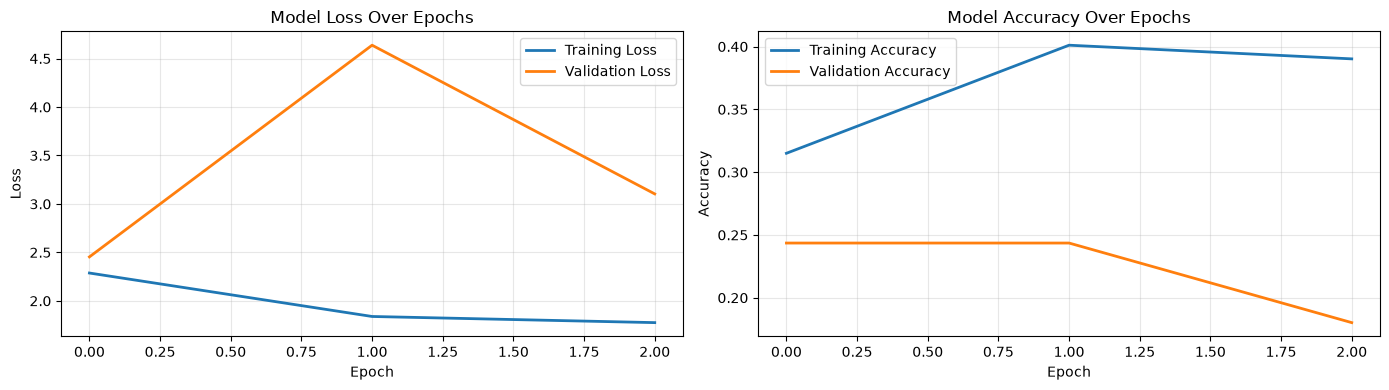

Training plots saved as 'training_history.png'


In [13]:
# Save the model
model.save('waste_classification_cnn_model.h5')
print("\nModel saved as 'waste_classification_cnn_model.h5'")
 
# Evaluate on validation set
print("\nEvaluating on validation set...")
val_loss, val_accuracy = model.evaluate(val_normalized, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
 
# Plot training history
print("\nGenerating training plots...")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("Training plots saved as 'training_history.png'")

In [14]:
print("\nGenerating Classification Report...")
val_predictions = []
val_true_labels = []
 
for images, labels in val_normalized:
    predictions = model.predict(images, verbose=0)
    pred_classes = np.argmax(predictions, axis=1)
    val_predictions.extend(pred_classes)
    val_true_labels.extend(labels.numpy())
 
print("\nClassification Report:")
print(classification_report(val_true_labels, val_predictions, target_names=class_names))


Generating Classification Report...

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.00      0.00      0.00        69
       glass       0.00      0.00      0.00       102
       metal       0.00      0.00      0.00        88
       paper       0.24      1.00      0.39       123
     plastic       0.00      0.00      0.00        89
       trash       0.00      0.00      0.00        34

    accuracy                           0.24       505
   macro avg       0.04      0.17      0.07       505
weighted avg       0.06      0.24      0.10       505



d:\DEEP_LEARNING\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\DEEP_LEARNING\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\DEEP_LEARNING\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


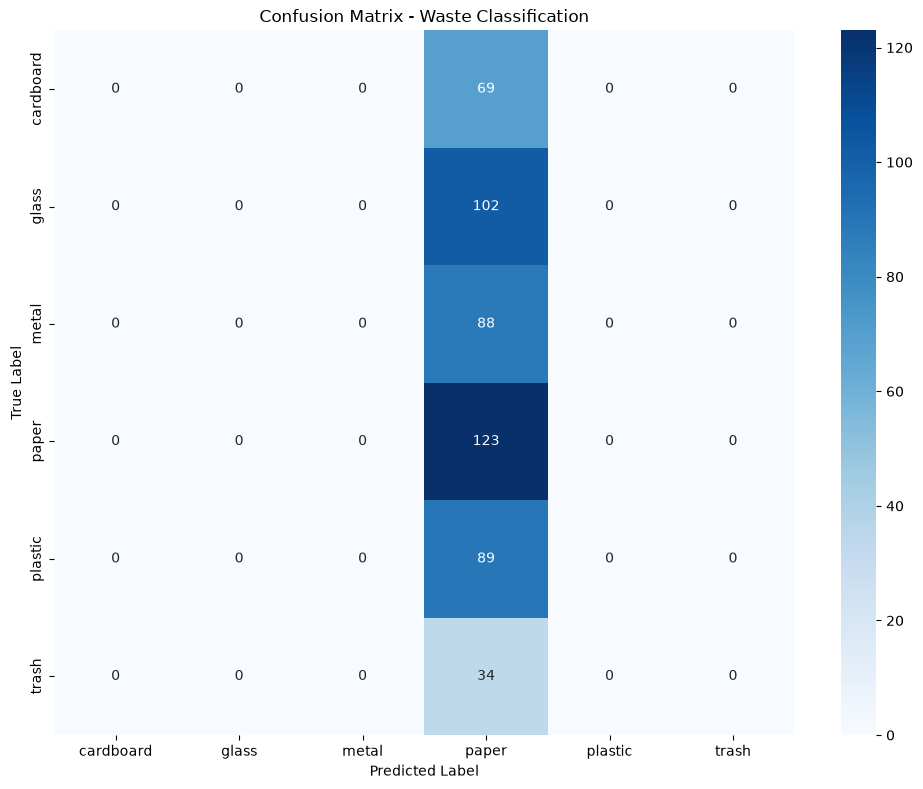

Confusion matrix saved as 'confusion_matrix.png'


In [15]:
cm = confusion_matrix(val_true_labels, val_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Waste Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")
 

In [16]:
# Function to predict on single image
def predict_waste_type(image_path):
    """Predict waste type for a single image"""
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = normalization_layer(img_array)
    
    prediction = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])
    
    return class_names[predicted_class], confidence
 
print("\n" + "="*60)
print("="*60)
print(f"Final Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"Number of Classes: {num_classes}")
print(f"Classes: {', '.join(class_names)}")
print("="*60)
 


Final Validation Accuracy: 24.36%
Number of Classes: 6
Classes: cardboard, glass, metal, paper, plastic, trash
